In [1]:
# import bibliotek
import pandas as pd
import numpy as np

In [2]:
# wczytanie plików
account_info = pd.read_csv("data/da_fitly_account_info.csv")
customer_support = pd.read_csv("data/da_fitly_customer_support.csv")
user_activity = pd.read_csv("data/da_fitly_user_activity.csv")

In [3]:
# utworzenie schowka do kolejnych kontroli
datasets = {
    "account_info": account_info,
    "customer_support": customer_support,
    "user_activity": user_activity
}

In [4]:
# wyświetlenie tabel
for name, df in datasets.items():
    print(f"{name.upper()}")
    display(df.head())

ACCOUNT_INFO


,customer_id,email,state,plan,plan_list_price,churn_status
0,C10000,user10000@example.com,New Jersey,Enterprise,105,Y
1,C10001,user10001@example.net,Louisiana,Basic,22,Y
2,C10002,user10002@example.net,Oklahoma,Basic,24,NaN
3,C10003,user10003@example.com,Michigan,Free,0,NaN
4,C10004,user10004@example.com,Texas,Enterprise,119,NaN


CUSTOMER_SUPPORT


,ticket_time,user_id,channel,topic,resolution_time_hours,state,comments
0,2025-06-13 05:55:17.154573,10125,chat,technical,11.48,1,NaN
1,2025-08-06 13:21:54.539551,10109,chat,account,1.01,0,NaN
2,2025-08-22 12:39:35.718663,10149,chat,technical,10.09,0,Erase my data from your systems.
3,2025-06-07 02:49:46.986055,10268,phone,account,9.10,1,NaN
4,2025-07-25 00:24:38.945079,10041,phone,other,2.28,1,NaN


USER_ACTIVITY


,event_time,user_id,event_type
0,2025-09-08 15:05:39.422721,10118,watch_video
1,2025-09-08 08:15:05.264103,10220,watch_video
2,2025-11-14 06:28:35.207671,10009,share_workout
3,2025-08-20 16:53:38.682901,10227,read_article
4,2025-07-24 16:47:31.728422,10123,track_workout


In [5]:
#liczba rekodrów i kolumn
for name, df in datasets.items():
    print(f"{name}:")
    print(f"Liczba rekordów: {df.shape[0]}")
    print(f"Liczba kolumn: {df.shape[1]}")
    print()

account_info:
Liczba rekordów: 400
Liczba kolumn: 6

customer_support:
Liczba rekordów: 918
Liczba kolumn: 7

user_activity:
Liczba rekordów: 445
Liczba kolumn: 3



In [6]:
dataset_overview = pd.DataFrame({
    name: {
        "rows": df.shape[0],
        "columns": df.shape[1]
    }
    for name, df in datasets.items()
}).T

display(dataset_overview)

,rows,columns
account_info,400,6
customer_support,918,7
user_activity,445,3


The analysis uses three datasets: account information (400 records, 6 columns), customer support (918 records, 7 columns), and user activity (445 records, 3 columns).

In [7]:
# sprawdzenie nazw kolumn
for name, df in datasets.items():
    print(f"\n{name.upper()}")
    print(df.columns.tolist())


ACCOUNT_INFO
['customer_id', 'email', 'state', 'plan', 'plan_list_price', 'churn_status']

CUSTOMER_SUPPORT
['ticket_time', 'user_id', 'channel', 'topic', 'resolution_time_hours', 'state', 'comments']

USER_ACTIVITY
['event_time', 'user_id', 'event_type']


- w account_info występuje churn_status, a nie churn;
- w customer_support występuje dodatkowa kolumna comments.
rozbieżności między plikami a tabelą z dokumerntacją

In [8]:
# sprawdzenie typów danych
for name, df in datasets.items():
    print(f"\n{name.upper()}")
    print(df.dtypes)


ACCOUNT_INFO
customer_id        object
email              object
state              object
plan               object
plan_list_price     int64
churn_status       object
dtype: object

CUSTOMER_SUPPORT
ticket_time               object
user_id                    int64
channel                   object
topic                     object
resolution_time_hours    float64
state                      int64
comments                  object
dtype: object

USER_ACTIVITY
event_time    object
user_id        int64
event_type    object
dtype: object


Kolumny ticket_time i event_time są początkowo wczytywane jako object, mimo że reprezentują daty.

In [9]:
# sprawdzanie brakujących wartości
for name, df in datasets.items():
    print(f"\n{name.upper()}")
    missing = df.isna().sum()
    display(missing.to_frame(name="missing_count"))


ACCOUNT_INFO


,missing_count
customer_id,0
email,0
state,0
plan,0
plan_list_price,0
churn_status,286



CUSTOMER_SUPPORT


,missing_count
ticket_time,0
user_id,0
channel,0
topic,0
resolution_time_hours,0
state,0
comments,872



USER_ACTIVITY


,missing_count
event_time,0
user_id,0
event_type,0


Missing values were identified in churn_status and comments.

In [10]:
for name, df in datasets.items():
    print(f"\n{name.upper()}")
    unique_counts = df.nunique(dropna=True)
    display(unique_counts.to_frame(name="unique_values"))


ACCOUNT_INFO


,unique_values
customer_id,400
email,400
state,50
plan,4
plan_list_price,106
churn_status,1



CUSTOMER_SUPPORT


,unique_values
ticket_time,918
user_id,367
channel,4
topic,4
resolution_time_hours,735
state,2
comments,19



USER_ACTIVITY


,unique_values
event_time,445
user_id,246
event_type,4


customer_id ma 400 unikalnych wartości przy 400 rekordach. nie występują powtarzające się identyfikatory klientów.
churn_status ma tylko jedną unikalną niepustą wartość — Y. Pozostałe wartości są brakujące. Czy to oznacza, że brakującve - nie zrezygnował?

In [11]:
# sprawdzenie rozkładu zmiennych, które nas interesują ze wzgledu na badanie
# ACCOUNT_INFO
# plan subskrypcyjny
account_info["plan"].value_counts(dropna=False)

plan
Basic         118
Free          105
Enterprise     92
Pro            85
Name: count, dtype: int64

In [12]:
# stan
account_info["state"].value_counts(dropna=False)

state
Virginia          16
Vermont           14
Florida           14
Delaware          13
Colorado          12
Arizona           12
Montana           12
Idaho             11
Rhode Island      10
Alaska            10
North Dakota      10
Missouri          10
West Virginia      9
Pennsylvania       9
Ohio               9
Texas              9
Michigan           9
Massachusetts      9
Tennessee          9
Mississippi        9
Wisconsin          8
Washington         8
Utah               8
Hawaii             8
Connecticut        8
New Mexico         7
Minnesota          7
Illinois           7
Iowa               7
New York           7
Oklahoma           6
Louisiana          6
New Jersey         6
Kansas             6
South Carolina     6
Maryland           6
North Carolina     6
Nebraska           6
New Hampshire      6
Arkansas           6
Wyoming            6
Nevada             6
Indiana            6
Kentucky           5
Oregon             5
South Dakota       5
Maine              4
Califor

In [13]:
# churn_status
account_info["churn_status"].value_counts(dropna=False)

churn_status
NaN    286
Y      114
Name: count, dtype: int64

In [14]:
# cena subskrypcji
account_info["plan_list_price"].describe()

count    400.000000
mean      43.965000
std       45.263348
min        0.000000
25%        0.000000
50%       26.000000
75%       77.250000
max      148.000000
Name: plan_list_price, dtype: float64

In [15]:
#CUSTOMER_STATUS
#kanał kontaktu
customer_support["channel"].value_counts(dropna=False)

channel
email    298
chat     294
phone    287
-         39
Name: count, dtype: int64

 są "-" które wskazuja na braki w danych wcześniej niewykryte

In [16]:
# temat zgłoszenia
customer_support["topic"].value_counts(dropna=False)

topic
billing      239
other        228
technical    226
account      225
Name: count, dtype: int64

In [17]:
# state
customer_support["state"].value_counts(dropna=False)

state
1    504
0    414
Name: count, dtype: int64

Brak informacji co oznacza 0 i 1 w state.

In [18]:
# czas zgłoszeń
customer_support["resolution_time_hours"].describe()

count    918.000000
mean      10.391362
std        7.079888
min        0.520000
25%        5.112500
50%        9.040000
75%       13.137500
max       32.460000
Name: resolution_time_hours, dtype: float64

In [19]:
# sprawdzanie zakresu dat na nowej, tymczasowej kolumnie
ticket_dates = pd.to_datetime(
    customer_support["ticket_time"],
    errors="coerce"
)
print(ticket_dates.min())
print(ticket_dates.max())
print(ticket_dates.isna().sum())

2025-06-05 15:32:33.005817
2025-12-01 22:01:58.485299
0


In [20]:
# USER ACTIVITY

In [21]:
# rodzaj zdarzenia
user_activity["event_type"].value_counts(dropna=False)

event_type
read_article     125
watch_video      120
track_workout    108
share_workout     92
Name: count, dtype: int64

In [22]:
# sprawdzanie zakresu dat na nowej, tymczasowej kolumnie
user_activity2 = pd.to_datetime(
    user_activity["event_time"],
    errors="coerce"

)
print(user_activity2.min())
print(user_activity2.max())
print(user_activity2.isna().sum())

2025-06-05 10:14:53.039663
2025-12-01 21:12:13.342817
0


The plan column contains four categories: Free, Basic, Pro, and Enterprise, consistent with the product documentation. No missing values were identified.
The churn_status column contains 114 values recorded as Y and 286 missing values. The meaning of missing churn statuses requires further investigation. W przypadku customer_support["channel"] występowanie 39 wartości -.
The numerical columns were checked for their minimum, maximum, and descriptive statistics.
No negative values were identified in the plan_list_price or resolution_time_hours columns.
The ticket_time and event_time columns were successfully converted to datetime format for validation purposes.
Both datasets contain records from June to December 2025.
No invalid date values were identified.

In [23]:
#sprawdzenie duplikatów
for name, df in datasets.items():
    print(f"\n{name.upper()}")
    duplicated_sum = df.duplicated().sum()
    print("Liczba duplikatów:", duplicated_sum)


ACCOUNT_INFO
Liczba duplikatów: 0

CUSTOMER_SUPPORT
Liczba duplikatów: 0

USER_ACTIVITY
Liczba duplikatów: 0


In [24]:
# sprawdzenie unilalności identyfikatorów
account_info["customer_id"].duplicated().sum()

np.int64(0)

In [25]:
#sprawdzenie zduplikowanych zgłoszeń
customer_support.duplicated(subset=["user_id", "ticket_time"]).sum()

np.int64(0)

In [26]:
user_activity.duplicated(subset=["user_id", "event_time", "event_type"]).sum()

np.int64(0)

Nie wykryto powtarzających się kombinacji identyfikatora klienta i czasu zgłoszenia, jednak nie można tego wykluczyć ze 100% pewnością, bo nie ma żadnych jednoznacznych identyfikatorów.

Duplicate Validation
All three datasets were checked for duplicate records.
No exact duplicate rows were identified in any dataset.
The customer_id column in account_info contains 400 unique identifiers, confirming that each customer is represented by a single record.
No duplicate combinations of user_id and ticket_time were identified in customer_support.
No duplicate combinations of user_id, event_time and event_type were identified in user_activity.
No records were removed during duplicate validation.
However, the absence of unique ticket and event identifiers prevents us from definitively ruling out all logical duplicates.

In [27]:
# Sprawdzenie zgodności identyfikatorów między zbiorami
# czy użytkowników występujących w customer_support i user_activity można odnaleźć w tabeli account_info, po to aby je połączyć

In [28]:
account_info["customer_id"].head()

0    C10000
1    C10001
2    C10002
3    C10003
4    C10004
Name: customer_id, dtype: object

In [29]:
customer_support["user_id"].sort_values().head()

80     10000
337    10000
595    10000
56     10001
472    10001
Name: user_id, dtype: int64

In [30]:
user_activity["user_id"].sort_values().head()

60     10000
224    10000
112    10000
39     10001
161    10002
Name: user_id, dtype: int64

Ujednolicamy zapis, tj dodajemy C z datasetów customer support oraz user activity

In [31]:
support_id = "C" + customer_support["user_id"].astype(str)

In [32]:
activity_id = "C" + user_activity["user_id"].astype(str)

nie zmieniamy oryginalnych danych. Tworzymy jedynie dwie dodatkowe zmienne, które wykorzystamy do porównania identyfikatorów.

In [33]:
# sprawdzamy czy identifikatory wszystkie w tych dwóch datasetach występują w głównym zbiorze
(~support_id.isin(account_info["customer_id"])).sum()

np.int64(0)

In [34]:
(~activity_id.isin(account_info["customer_id"])).sum()

np.int64(0)

In [35]:
# i jeszcze czy są klienci bez zgłoszeń i aktywności
(~account_info["customer_id"].isin(support_id)).sum()

np.int64(33)

In [36]:
(~account_info["customer_id"].isin(activity_id)).sum()

np.int64(154)

Nie oznacza jednak automatycznie, że 154 klientów nigdy nie korzystało z aplikacji. W danych mogą występować luki, ponieważ Lead Engineer potwierdza, że awarie systemów mogą prowadzić do brakujących rekordów.

Identifier Consistency
Customer identifiers were checked across all three datasets.
The account_info dataset uses identifiers with a "C" prefix, while customer_support and user_activity use numerical identifiers.
Identifiers were temporarily standardized to allow comparison.
All records from customer_support and user_activity could be matched to existing customer accounts.
However, 33 customers have no recorded support tickets, and 154 customers have no recorded activity.
No records were removed during this validation.

## WALIDACJA DANYCH ##

In [37]:
# ACCOUNT INFO

In [38]:
# czy wszystko w account info zaczyna się od kolumny?
account_info["customer_id"].str.fullmatch(r"C\d+").value_counts()

customer_id
True    400
Name: count, dtype: int64

In [39]:
# Tak

customer_id: The column contains 400 unique customer identifiers with no missing or duplicate values. All identifiers follow the observed format of the letter C followed by digits. No cleaning was required.

In [40]:
# czy w e-mail wszystko ma @?
account_info["email"].str.contains("@", regex=False).value_counts()

email
True    400
Name: count, dtype: int64

In [41]:
# Tak
# czy na pewno nie ma nigdzie spacji?
account_info["email"].str.contains(" ", regex=False).sum()

np.int64(0)

email: All 400 email addresses are unique and non-missing. Basic format checks identified no addresses without an @ symbol or containing spaces. No cleaning was required.

In [42]:
#state powinny byc w USA, bo tak mówi Product Manager

In [43]:
sorted(account_info["state"].unique())

['Alabama',
 'Alaska',
 'Arizona',
 'Arkansas',
 'California',
 'Colorado',
 'Connecticut',
 'Delaware',
 'Florida',
 'Georgia',
 'Hawaii',
 'Idaho',
 'Illinois',
 'Indiana',
 'Iowa',
 'Kansas',
 'Kentucky',
 'Louisiana',
 'Maine',
 'Maryland',
 'Massachusetts',
 'Michigan',
 'Minnesota',
 'Mississippi',
 'Missouri',
 'Montana',
 'Nebraska',
 'Nevada',
 'New Hampshire',
 'New Jersey',
 'New Mexico',
 'New York',
 'North Carolina',
 'North Dakota',
 'Ohio',
 'Oklahoma',
 'Oregon',
 'Pennsylvania',
 'Rhode Island',
 'South Carolina',
 'South Dakota',
 'Tennessee',
 'Texas',
 'Utah',
 'Vermont',
 'Virginia',
 'Washington',
 'West Virginia',
 'Wisconsin',
 'Wyoming']

state: The column contains 50 unique US state names, consistent with the company's current geographical coverage. No missing values or invalid state names were identified. No cleaning was required.

In [44]:
# plam wg Product Managera musi mieć 4 wartości: "Free, Basic, Pro, Enterprise" i tylko takie są

plan: The column contains four categories: Free, Basic, Pro, and Enterprise. All 400 records match the expected plan types specified by the Product Manager. No missing or invalid values were identified. No cleaning was required.

In [45]:
# plan_list_price oznacza rzeczywistą cenę zapłaconą przez klienta. Nie było wartości ujemnych więc najlepiej sprawdić i pogrupowac i jak to wygląda

In [46]:
account_info.groupby("plan")["plan_list_price"].agg(["count", "min", "max", "mean"])

,count,min,max,mean
plan,,,,
Basic,118,10,30,19.872881
Enterprise,92,81,148,116.010870
Free,105,0,0,0.000000
Pro,85,32,80,53.741176


ceny w ramach poszczeólnych planów sa różne ale to nie moze byc błąd bo nie ma o tym info w dokumentacji

plan_list_price: The column contains numerical values ranging from 0 to 148, with no missing or negative values. All Free plan customers have a price of 0, while paid plans have positive prices. No cleaning was required.

In [47]:
# churn: klient zostaje oznaczony jako churned po anulowaniu subskrypcji, czyli jak nie ma churn to nie anulował

In [48]:
# czyszczę: zachowują oryginalne dane i tworze kopię
account_info_clean = account_info.copy()

In [49]:
# zamiana Nan na N
account_info_clean["churn_status"] = account_info_clean["churn_status"].fillna("N")
account_info_clean["churn_status"].value_counts(dropna=False)

churn_status
N    286
Y    114
Name: count, dtype: int64

churn_status: The column originally contained 114 values marked as Y and 286 missing values.

According to the Product Manager, customers are marked as churned once their subscription has been cancelled.

Based on this information, we assumed that missing values indicate customers who have not cancelled their subscriptions.
Therefore, all 286 missing values were replaced with N.

After cleaning, the column contains two categories: Y (114 customers) and N (286 customers), with no missing values remaining.


In [50]:
# odsetek, którzy anulowali
account_info_clean["churn_status"].value_counts(normalize=True) * 100

churn_status
N    71.5
Y    28.5
Name: proportion, dtype: float64

In [51]:
# w dkumntacji: kolumna signup_date
# sprawdzamy:
account_info.columns

Index(['customer_id', 'email', 'state', 'plan', 'plan_list_price',
       'churn_status'],
      dtype='object')

Additional observation: The Product Manager refers to a signup_date field, but this column is not present in the provided account_info dataset. Therefore, customer tenure and signup cohort analysis cannot be performed using the available account data.

In [52]:
account_info_clean.head()

,customer_id,email,state,plan,plan_list_price,churn_status
0,C10000,user10000@example.com,New Jersey,Enterprise,105,Y
1,C10001,user10001@example.net,Louisiana,Basic,22,Y
2,C10002,user10002@example.net,Oklahoma,Basic,24,N
3,C10003,user10003@example.com,Michigan,Free,0,N
4,C10004,user10004@example.com,Texas,Enterprise,119,N


In [53]:
# CUSTOMER_SUPPORT

In [54]:
# ticket_time oznacza moment otrzymania zgłoszenia w strefie Pacific;

In [55]:
# Z wcześniejszego profilowania:
# - kolumna zawiera 918 wartości;
# - nie występują braki;
# - wszystkie wartości można przekonwertować na daty;
# - daty obejmują okres od 5 czerwca do 1 grudnia 2025 roku.

In [56]:
# Kolumna została pierwotnie wczytana jako object.
# Powinniśmy przekonwertować ją na typ datetime.

In [57]:
# pracujemy na kopii
customer_support_clean = customer_support.copy()

In [58]:
customer_support_clean["ticket_time"] = pd.to_datetime(customer_support_clean["ticket_time"])
customer_support_clean["ticket_time"].dtype

dtype('<M8[ns]')

ticket_time: The column contains 918 non-missing values. All values were successfully converted to datetime. The dates range from June 5 to December 1, 2025. According to the Product Manager, ticket timestamps are recorded in Pacific time. No records were removed.

In [59]:
# Z wcześniejszego profilowania:
# nie występują braki;
# jest 367 unikalnych użytkowników;
# wszystkie identyfikatory można dopasować do account_info po ujednoliceniu formatu;
# powtarzające się identyfikatory są oczekiwane, ponieważ klient może mieć wiele zgłoszeń.
# Na razie niczego nie zmieniamy.
# user_id pozostaje w oryginalnym formacie liczbowym. Ujednolicenie identyfikatorów wykonamy podczas przygotowywania danych do połączenia.

user_id: The column contains 367 unique user identifiers with no missing values. 
All identifiers can be matched to customer accounts after format standardization.
Repeated identifiers are expected because customers may submit multiple support tickets.
No cleaning was required at this stage.

In [60]:
# dla kolumny channel występują wartości "-", ktyóre praswdopodobnie wskazują brak danych
# przypiszemy wartośc unknown bo nie mamy informacji o tym jaki był ten kanał kontaktu i będzoe to bardziej jasne

In [61]:
customer_support_clean["channel"] = (customer_support_clean["channel"].replace("-", "Unknown"))

In [62]:
customer_support_clean["channel"].value_counts(dropna=False)

channel
email      298
chat       294
phone      287
Unknown     39
Name: count, dtype: int64

channel: The column contains four distinct values: email, chat, phone, and "-". A total of 39 records contained the placeholder "-".

These values were replaced with "Unknown" because the original contact channel could not be determined.

All records were retained.

In [63]:
#topic - wszystko ok
# Występują cztery kategorie.
# Nie ma brakujących wartości ani różnych wariantów zapisu tych samych kategorii.

topic: The column contains four categories: billing, other, technical, and account. No missing values or inconsistent category labels were identified. No cleaning was required.

In [64]:
# resolution_time_hours - jest to czas od utworzenia zgłoszenia do jego zamknięcia; czas rozwiązania zgłoszenia jest obliczany podczas procesu ETL.

resolution_time_hours: The column contains 918 numerical values, ranging from 0.52 to 32.46 hours. No missing or negative values were identified.

According to the Product Manager, this field measures the time between ticket creation and closure.

No cleaning was required.


nie możemy niezależnie zweryfikować poprawności obliczenia czasu rozwiązania, ponieważ nie otrzymaliśmy osobnej daty zamknięcia zgłoszenia.

In [65]:
# state - 0 i 1, brak braków ale W account_info kolumna state oznacza stan USA. Natomiast w customer_support przyjmuje wartości binarne. 
# Może oznaczać cos innego niż state w account_info
# brak informacji w dokumnetacji o tym co oznacza 1 i 0
# zmiana nazwy kolumny, żeby nie pomylic jej przy łączeniu danych

In [66]:
customer_support_clean = customer_support_clean.rename(columns={"state": "state_code"})

state: The column contains two values, 0 and 1, with no missing values.

The meaning of these values is not defined in the provided documentation. Unlike the state column in account_info, this field does not contain geographical information.

The column was renamed to state_code to avoid confusion during data integration.

The original values were retained without modification.

In [67]:
# comments - komentarze, brak w dokumentacji, ciągi znaków, nie trzeba zmieniac ani uzupełniać

comments: The column contains 46 non-missing values and 872 missing values.

The non-missing comments concern personal data deletion requests.

Missing values were retained, as the documentation does not establish that a comment is required for every support ticket.

The original comments were preserved in the source data but excluded from the churn analysis due to their sensitive content.

Customer Support — Validation Summary
The customer_support dataset contains 918 records and 7 columns.
All columns were assessed for missing values, data types, unique values, and consistency with the available documentation.
The ticket_time column was converted to datetime.
The channel column contained 39 placeholder values recorded as "-". These were replaced with "Unknown" because the original contact channels could not be determined.
The state column contains binary values whose meaning is not defined in the documentation. It was renamed to ticket_state_code to avoid confusion with geographical information in account_info.
The comments column contains 46 non-missing values concerning personal data deletion requests. These comments were excluded from the churn analysis.
No records were removed during data cleaning.
After validation, the dataset contains 918 records and 7 columns.

In [68]:
customer_support_clean.head()

,ticket_time,user_id,channel,topic,resolution_time_hours,state_code,comments
0,2025-06-13 05:55:17.154573,10125,chat,technical,11.48,1,NaN
1,2025-08-06 13:21:54.539551,10109,chat,account,1.01,0,NaN
2,2025-08-22 12:39:35.718663,10149,chat,technical,10.09,0,Erase my data from your systems.
3,2025-06-07 02:49:46.986055,10268,phone,account,9.10,1,NaN
4,2025-07-25 00:24:38.945079,10041,phone,other,2.28,1,NaN


In [69]:
# USER_ACTIVITY

In [70]:
# event_time — czas zarejestrowania zdarzenia;

In [71]:
# Z poprzedniego etapu profilowania:
# - kolumna zawiera 445 wartości;
# - nie występują braki;
# - wszystkie wartości można przekonwertować na daty;
# - daty obejmują okres od 5 czerwca do 1 grudnia 2025 roku;
# - pierwotny typ danych to object.

In [72]:
# potrzebna zmiana na date time na skopiowanym datasecie

In [73]:
user_activity_clean = user_activity.copy()

In [74]:
user_activity_clean["event_time"] = pd.to_datetime(user_activity_clean["event_time"])

In [75]:
user_activity_clean["event_time"].dtype

dtype('<M8[ns]')

event_time: The column contains 445 non-missing values. All timestamps were successfully converted to datetime. The dates range from June 5 to December 1, 2025. No invalid date values were identified. No records were removed.

In [76]:
# user_id — identyfikator użytkownika;

In [77]:
# kolumna zawiera 445 wartości;
# występuje 246 unikalnych użytkowników;
# nie ma brakujących wartości;
# wszystkie identyfikatory można dopasować do account_info po ujednoliceniu formatu.
# duplikaty nie są błędem - wiele aktywności

user_id: The column contains 246 unique user identifiers with no missing values. All identifiers can be matched to customer accounts after format standardization. Repeated identifiers are expected because users can perform multiple activities. No cleaning was required.

In [78]:
# event_type — rodzaj aktywności.
# wystepuje 4 typy zdarzeń bo sprawdziłam
# nic nie zmieniamy

event_type: The column contains four categories: read_article, watch_video, track_workout, and share_workout. No missing values or inconsistent category labels were identified. All categories represent plausible user activities. No cleaning was required.

User Activity — Validation Summary
The user_activity dataset contains 445 records and 3 columns.
All columns were checked for missing values, data types, unique values, and consistency with the available documentation.
The event_time column was successfully converted to datetime. All timestamps are valid and range from June 5 to December 1, 2025.
The user_id column contains 246 unique users. All identifiers can be matched to customer accounts after format standardization.
The event_type column contains four categories: read_article, watch_video, track_workout, and share_workout. No missing values or inconsistent labels were identified.
No records were removed during validation.
After validation, the dataset contains 445 records and 3 columns.

In [79]:
# W account_info  400 klientów, natomiast w user_activity występują zdarzenia dotyczące tylko 246 z nich.
#dla 154 klientów nie ma zarejestrowanej aktywności.
# Lead Engineer informuje, że awarie systemów mogą powodować luki w danych, które nie są automatycznie uzupełniane 
# dlatego te braku nie oznaczają braku aktywności ale moga byc błedami

Data Limitation: No activity records were available for 154 customers. This may indicate a lack of recorded engagement, but missing activity logs cannot be ruled out. Therefore, the absence of records should not automatically be interpreted as confirmed user inactivity.

In [80]:
user_activity_clean.head()

,event_time,user_id,event_type
0,2025-09-08 15:05:39.422721,10118,watch_video
1,2025-09-08 08:15:05.264103,10220,watch_video
2,2025-11-14 06:28:35.207671,10009,share_workout
3,2025-08-20 16:53:38.682901,10227,read_article
4,2025-07-24 16:47:31.728422,10123,track_workout


## Agregacja danych ##

Stworzymy tabele
- support_full	Analiza szczegółowych informacji o zgłoszeniach w powiązaniu z klientami.
- support_summary   Zagregowane informacje o zgłoszeniach — jeden wiersz na klienta.
- activity_full	Analiza szczegółowych informacji o aktywności w powiązaniu z klientami.
- activity_summary  Zagregowane informacje o aktywności — jeden wiersz na klienta.
- customer_analysis	Łączna analiza planów, zgłoszeń, aktywności i churn.

Data Integration

The three datasets were integrated using customer identifiers.

To preserve the original level of detail, separate datasets were created for customer support and user activity, enriched with account information.

Additionally, customer support and activity records were aggregated at the customer level and combined with account information.

The resulting customer-level dataset contains information about subscription plans, churn status, support interactions, and user engagement.

This approach enables an integrated analysis of potential churn drivers while preserving the detailed records for further investigation.


In [81]:
# łączenie customer_support_clean i account_info_clean

In [82]:
# ujednolicenie identyfikatorów

In [83]:
support = customer_support_clean.copy()
support["customer_id"] = "C" + support["user_id"].astype(str)

In [84]:
# połączenie
support_full = support.merge(account_info_clean,on="customer_id",how="left",suffixes=("_support", "_account"))

In [85]:
support_full.shape

(918, 13)

In [86]:
support_full.head()

,ticket_time,user_id,channel,topic,resolution_time_hours,state_code,comments,customer_id,email,state,plan,plan_list_price,churn_status
0,2025-06-13 05:55:17.154573,10125,chat,technical,11.48,1,NaN,C10125,user10125@example.com,Montana,Free,0,N
1,2025-08-06 13:21:54.539551,10109,chat,account,1.01,0,NaN,C10109,user10109@example.com,Tennessee,Enterprise,136,N
2,2025-08-22 12:39:35.718663,10149,chat,technical,10.09,0,Erase my data from your systems.,C10149,user10149@example.com,Louisiana,Free,0,N
3,2025-06-07 02:49:46.986055,10268,phone,account,9.10,1,NaN,C10268,user10268@example.net,Vermont,Basic,24,N
4,2025-07-25 00:24:38.945079,10041,phone,other,2.28,1,NaN,C10041,user10041@example.org,Virginia,Enterprise,121,N


In [87]:
# łączenie user_activity_clean i account_info_clean

In [88]:
activity = user_activity_clean.copy()
activity["customer_id"] = "C" + activity["user_id"].astype(str)
activity_full = activity.merge(account_info_clean, on="customer_id", how="left")

In [89]:
activity_full.shape

(445, 9)

In [90]:
activity_full.head()

,event_time,user_id,event_type,customer_id,email,state,plan,plan_list_price,churn_status
0,2025-09-08 15:05:39.422721,10118,watch_video,C10118,user10118@example.com,Delaware,Free,0,N
1,2025-09-08 08:15:05.264103,10220,watch_video,C10220,user10220@example.org,Arkansas,Basic,15,N
2,2025-11-14 06:28:35.207671,10009,share_workout,C10009,user10009@example.com,Virginia,Free,0,N
3,2025-08-20 16:53:38.682901,10227,read_article,C10227,user10227@example.net,Wyoming,Basic,23,N
4,2025-07-24 16:47:31.728422,10123,track_workout,C10123,user10123@example.com,Minnesota,Basic,19,N


In [91]:
# przygotowanie support_summary

In [92]:
# liczba zgłoszeń każdego klienta
ticket_counts = support_full.groupby("customer_id").size().reset_index(name="ticket_count")

In [93]:
ticket_counts.head()

,customer_id,ticket_count
0,C10000,3
1,C10001,4
2,C10002,3
3,C10003,1
4,C10004,4


In [94]:
# liczba zgłoszeń według tematu
topic_counts = pd.crosstab(support_full["customer_id"], support_full["topic"])
topic_counts = topic_counts.add_prefix("topic_")
topic_counts = topic_counts.reset_index()

In [95]:
topic_counts.head()

topic,customer_id,topic_account,topic_billing,topic_other,topic_technical
0,C10000,1,1,1,0
1,C10001,0,2,1,1
2,C10002,0,0,2,1
3,C10003,0,0,1,0
4,C10004,0,2,0,2


In [96]:
# liczba zgłoszeń według kanału

In [97]:
channel_counts = pd.crosstab(support_full["customer_id"],support_full["channel"])
channel_counts = channel_counts.add_prefix("channel_")
channel_counts = channel_counts.reset_index()

In [98]:
channel_counts.head()

channel,customer_id,channel_Unknown,channel_chat,channel_email,channel_phone
0,C10000,0,1,2,0
1,C10001,0,0,1,3
2,C10002,0,2,1,0
3,C10003,1,0,0,0
4,C10004,1,1,1,1


In [99]:
# czas rozwiązania zgłoszeń

In [100]:
resolution_stats = support_full.groupby("customer_id")["resolution_time_hours"].agg(["mean", "max"])
resolution_stats = resolution_stats.rename(columns={"mean": "avg_resolution_hours", "max": "max_resolution_hours"})
resolution_stats = resolution_stats.reset_index()

In [101]:
resolution_stats.head()

,customer_id,avg_resolution_hours,max_resolution_hours
0,C10000,21.446667,23.77
1,C10001,17.542500,26.44
2,C10002,6.433333,10.32
3,C10003,2.190000,2.19
4,C10004,8.542500,10.45


In [102]:
# połączenie tabel czastkowych

In [103]:
support_summary = ticket_counts.merge(topic_counts, on="customer_id", how="left")

In [104]:
support_summary = support_summary.merge(channel_counts, on="customer_id", how="left")

In [105]:
support_summary = support_summary.merge(resolution_stats, on="customer_id", how="left")

In [106]:
support_summary.head()

,customer_id,ticket_count,topic_account,topic_billing,topic_other,topic_technical,channel_Unknown,channel_chat,channel_email,channel_phone,avg_resolution_hours,max_resolution_hours
0,C10000,3,1,1,1,0,0,1,2,0,21.446667,23.77
1,C10001,4,0,2,1,1,0,0,1,3,17.542500,26.44
2,C10002,3,0,0,2,1,0,2,1,0,6.433333,10.32
3,C10003,1,0,0,1,0,1,0,0,0,2.190000,2.19
4,C10004,4,0,2,0,2,1,1,1,1,8.542500,10.45


In [107]:
support_summary.shape

(367, 12)

In [108]:
customer_support.nunique(dropna=True).to_frame(name="unique_values")

,unique_values
ticket_time,918
user_id,367
channel,4
topic,4
resolution_time_hours,735
state,2
comments,19


Zgadza się  - w customer_support występuje 367 unikalnych klientów.

In [109]:
# przygotowanie activity_summary

In [110]:
# liczba aktywności każdego klienta
activity_counts = activity_full.groupby("customer_id").size().reset_index(name="activity_count")

In [111]:
activity_counts.head()

,customer_id,activity_count
0,C10000,3
1,C10001,1
2,C10002,1
3,C10003,1
4,C10004,4


In [112]:
# liczba aktywności według rodzaju
event_counts = pd.crosstab(activity_full["customer_id"], activity_full["event_type"])
event_counts = event_counts.add_prefix("event_")
event_counts = event_counts.reset_index()

In [113]:
event_counts.head()

event_type,customer_id,event_read_article,event_share_workout,event_track_workout,event_watch_video
0,C10000,2,0,0,1
1,C10001,1,0,0,0
2,C10002,1,0,0,0
3,C10003,0,0,1,0
4,C10004,0,0,1,3


In [114]:
# łączenie tabel czastkowych
activity_summary = activity_counts.merge(event_counts, on="customer_id", how="left")

In [115]:
activity_summary.head()

,customer_id,activity_count,event_read_article,event_share_workout,event_track_workout,event_watch_video
0,C10000,3,2,0,0,1
1,C10001,1,1,0,0,0
2,C10002,1,1,0,0,0
3,C10003,1,0,0,1,0
4,C10004,4,0,0,1,3


In [116]:
activity_summary.shape

(246, 6)

In [117]:
user_activity.nunique(dropna=True).to_frame(name="unique_values")

,unique_values
event_time,445
user_id,246
event_type,4


Zgadza się  - w user_activity występuje 246 unikalnych klientów.

In [118]:
# tworzenie customer_analysis z support_summary i activity_summary

In [119]:
# tabel bazowa 
customer_analysis = account_info_clean.copy()

In [120]:
customer_analysis = customer_analysis.merge(support_summary, on="customer_id",how="left")

In [121]:
customer_analysis = customer_analysis.merge(activity_summary,on="customer_id",how="left")

In [122]:
customer_analysis.shape

(400, 22)

In [123]:
customer_analysis.head()

,customer_id,email,state,plan,plan_list_price,churn_status,ticket_count,topic_account,topic_billing,topic_other,...,channel_chat,channel_email,channel_phone,avg_resolution_hours,max_resolution_hours,activity_count,event_read_article,event_share_workout,event_track_workout,event_watch_video
0,C10000,user10000@example.com,New Jersey,Enterprise,105,Y,3.0,1.0,1.0,1.0,...,1.0,2.0,0.0,21.446667,23.77,3.0,2.0,0.0,0.0,1.0
1,C10001,user10001@example.net,Louisiana,Basic,22,Y,4.0,0.0,2.0,1.0,...,0.0,1.0,3.0,17.542500,26.44,1.0,1.0,0.0,0.0,0.0
2,C10002,user10002@example.net,Oklahoma,Basic,24,N,3.0,0.0,0.0,2.0,...,2.0,1.0,0.0,6.433333,10.32,1.0,1.0,0.0,0.0,0.0
3,C10003,user10003@example.com,Michigan,Free,0,N,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,2.190000,2.19,1.0,0.0,0.0,1.0,0.0
4,C10004,user10004@example.com,Texas,Enterprise,119,N,4.0,0.0,2.0,0.0,...,1.0,1.0,1.0,8.542500,10.45,4.0,0.0,0.0,1.0,3.0


In [124]:
# sprawdzenie występowania brakujących danych
customer_analysis.isna().sum()

customer_id               0
email                     0
state                     0
plan                      0
plan_list_price           0
churn_status              0
ticket_count             33
topic_account            33
topic_billing            33
topic_other              33
topic_technical          33
channel_Unknown          33
channel_chat             33
channel_email            33
channel_phone            33
avg_resolution_hours     33
max_resolution_hours     33
activity_count          154
event_read_article      154
event_share_workout     154
event_track_workout     154
event_watch_video       154
dtype: int64

To się zgadza, bo nie wszyscy klienci występowali we wszystkioch tabelach. Nie wszscy klienci dokonywali zgłoszeń więc można brakujące wartości zamienić zerami.

Nalezy nieuzupełniac danych dla avg_resolution_hours i max_resolution_hours ponieważ, jeżeli klient nie miał żadnego zgłoszenia, nie możemy przypisać mu średniego czasu rozwiązania równego zero.

Ważne: zero w activity_count oznacza brak zdarzeń w dostarczonych danych, a nie potwierdzony brak korzystania z aplikacji.

In [125]:
count_columns = [
    "ticket_count",
    "topic_account",
    "topic_billing",
    "topic_other",
    "topic_technical",
    "channel_Unknown",
    "channel_chat",
    "channel_email",
    "channel_phone",
    "activity_count",
    "event_read_article",
    "event_share_workout",
    "event_track_workout",
    "event_watch_video"
]

In [126]:
customer_analysis[count_columns] = customer_analysis[count_columns].fillna(0)

In [127]:
customer_analysis[count_columns] = customer_analysis[count_columns].astype(int)

In [128]:
customer_analysis.shape

(400, 22)

In [129]:
customer_analysis["customer_id"].nunique()

400

In [130]:
customer_analysis["customer_id"].duplicated().sum()

np.int64(0)

In [131]:
customer_analysis["ticket_count"].sum()

np.int64(918)

In [132]:
customer_analysis["activity_count"].sum()

np.int64(445)

Data Integration

The three validated datasets were integrated using customer identifiers.

Customer support records were aggregated at the customer level to calculate the number of tickets, ticket counts by topic and channel, and average and maximum resolution times.

User activity records were aggregated to calculate the total number of recorded activities and the number of events of each type.

Both aggregated datasets were merged with account information using left joins, preserving all 400 customer accounts.

Missing ticket and activity counts resulting from the joins were replaced with zero, indicating that no corresponding records were found in the provided datasets.

Missing resolution times were retained for customers without support tickets.

The final customer-level dataset contains 400 records and 21 columns.

Validation confirmed that the aggregated counts account for all 918 support tickets and 445 activity events.

Detailed support and activity datasets were retained for further analysis.


## ANALIZA EKSPLORACYJNA - EDA ##

### univariate EDA ###

In [133]:
customer_analysis.head()

,customer_id,email,state,plan,plan_list_price,churn_status,ticket_count,topic_account,topic_billing,topic_other,...,channel_chat,channel_email,channel_phone,avg_resolution_hours,max_resolution_hours,activity_count,event_read_article,event_share_workout,event_track_workout,event_watch_video
0,C10000,user10000@example.com,New Jersey,Enterprise,105,Y,3,1,1,1,...,1,2,0,21.446667,23.77,3,2,0,0,1
1,C10001,user10001@example.net,Louisiana,Basic,22,Y,4,0,2,1,...,0,1,3,17.542500,26.44,1,1,0,0,0
2,C10002,user10002@example.net,Oklahoma,Basic,24,N,3,0,0,2,...,2,1,0,6.433333,10.32,1,1,0,0,0
3,C10003,user10003@example.com,Michigan,Free,0,N,1,0,0,1,...,0,0,0,2.190000,2.19,1,0,0,1,0
4,C10004,user10004@example.com,Texas,Enterprise,119,N,4,0,2,0,...,1,1,1,8.542500,10.45,4,0,0,1,3


In [134]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sns.set_style(style="whitegrid")

***1. Pytanie analityczne:*** Jak wygląda struktura klientów Fit.ly według rodzaju planu?

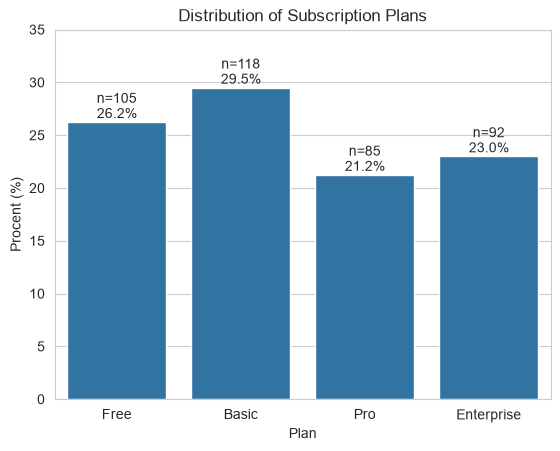

In [135]:
# rozkład poszczególnych planów 

order = ['Free', 'Basic', 'Pro', 'Enterprise']

ax = sns.countplot(
    data=customer_analysis,
    x='plan',
    stat='percent',
    order=order
)

counts = customer_analysis['plan'].value_counts().reindex(order, fill_value=0)

for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f'n={n}\n{p:.1f}%' for n, p in zip(counts, container.datavalues)]
    )

ax.set_ylim(0, 35)

plt.title("Distribution of Subscription Plans")
plt.ylabel('Procent (%)')
plt.xlabel('Plan')
plt.show()

Subscription Plan Distribution

The customer base consists of 400 customers across four subscription plans. Basic is the most common plan, with 118 (29,5%) customers, followed by Free (105, 26,2%), Enterprise (92, 23,0%), and Pro (85m 23,0).

The distribution indicates that customers are represented across all four subscription tiers.

***2. Pytanie analityczne:*** Jak rozkłada się czas rozwiązywania zgłoszeń klientów?

In [136]:
customer_support_clean["resolution_time_hours"].describe()

count    918.000000
mean      10.391362
std        7.079888
min        0.520000
25%        5.112500
50%        9.040000
75%       13.137500
max       32.460000
Name: resolution_time_hours, dtype: float64

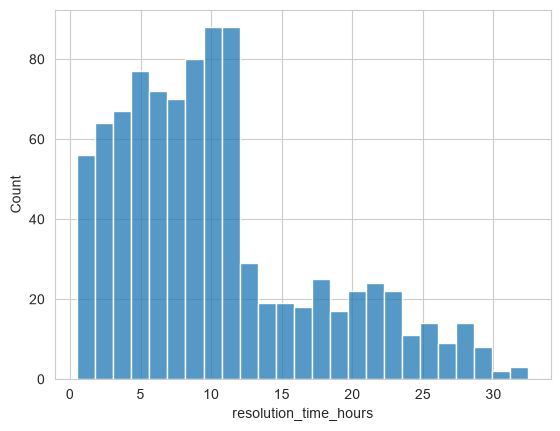

In [137]:
ax = sns.histplot(
    data=customer_support_clean,
    x='resolution_time_hours',
    bins=25
)

plt.show()

Ticket Resolution Time Distribution

The average ticket resolution time is 10.39 hours, while the median is 9.04 hours.

Resolution times range from 0.52 to 32.46 hours.

The mean exceeds the median, suggesting that longer resolution times increase the overall average.

Further analysis is required to determine whether resolution time is associated with customer churn.

    -> Różnice w wielkości grup oznaczają, że porównując churn pomiędzy planami, powinniśmy wykorzystywać udziały procentowe, a nie wyłącznie liczbę rezygnacji.


***3. Pytanie analityczne:*** Jak rozkładają się ceny subskrypcji wśród klientów Fit.ly?

In [138]:
customer_analysis["plan_list_price"].describe()

count    400.000000
mean      43.965000
std       45.263348
min        0.000000
25%        0.000000
50%       26.000000
75%       77.250000
max      148.000000
Name: plan_list_price, dtype: float64

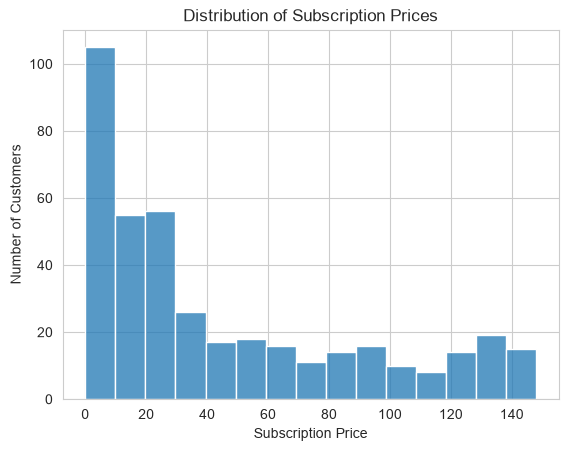

In [139]:
ax = sns.histplot(
    data=customer_analysis,
    x="plan_list_price",
    bins=15
)

plt.title("Distribution of Subscription Prices")
plt.xlabel("Subscription Price")
plt.ylabel("Number of Customers")

plt.show()

Ceny subskrypcji mieszczą się w przedziale od 0 do 148.
    
Średnia cena wynosi 43,97, natomiast mediana wynosi 26.
    
W rozkładzie występuje wyraźna grupa klientów z ceną równą zero. Są to użytkownicy darmowego planu Free, których jest 105.
    
Średnia jest wyższa od mediany, co oznacza, że wyższe ceny wpływają na podwyższenie średniej.
    
Zróżnicowanie cen jest również związane z występowaniem czterech różnych planów subskrypcyjnych.

    -> Warto sprawdzić, czy udział churn jest powiązany z wysokością ceny. Należy jednak uwzględnić rodzaj planu, ponieważ cena i plan są ze sobą powiązane.

***4. Pytanie analityczne:*** Jaki odsetek klientów Fit.ly jest oznaczony jako churned?

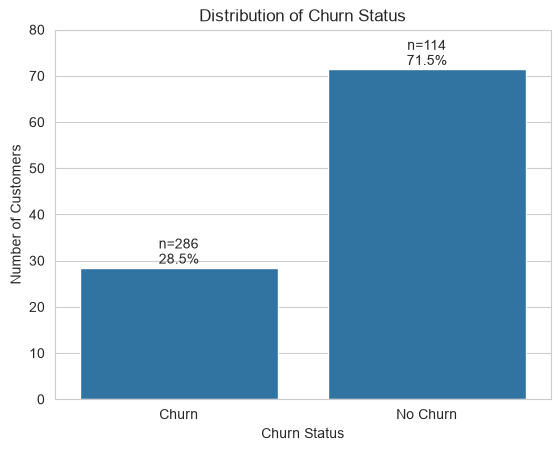

In [140]:
ax = sns.countplot(
    data=customer_analysis,
    x='churn_status',
    stat='percent',
)

ax.set_xticks(['N', 'Y'], labels=['No Churn', 'Churn'])

counts = customer_analysis['churn_status'].value_counts().reindex(['N', 'Y'], fill_value=0)

for container in ax.containers:
    ax.bar_label(container, labels=[f'n={n}\n{p:.1f}%' for n, p in zip(counts, container.datavalues)])

ax.set_ylim(0, 80)

plt.title("Distribution of Churn Status")
plt.xlabel("Churn Status")
plt.ylabel("Number of Customers")
plt.show()

Spośród 400 klientów 114 jest oznaczonych jako churned.

Stanowią oni 28,5% analizowanej bazy.

    -> Znaczenie dla dalszej analizy: Wartość 28,5% stanowi punkt odniesienia do porównywania udziału churn pomiędzy różnymi grupami klientów.

***5. Pytanie analityczne:*** Jak rozkłada się liczba zarejestrowanych aktywności wśród klientów Fit.ly?

In [141]:
customer_analysis["activity_count"].describe()

count    400.000000
mean       1.112500
std        1.139337
min        0.000000
25%        0.000000
50%        1.000000
75%        2.000000
max        5.000000
Name: activity_count, dtype: float64

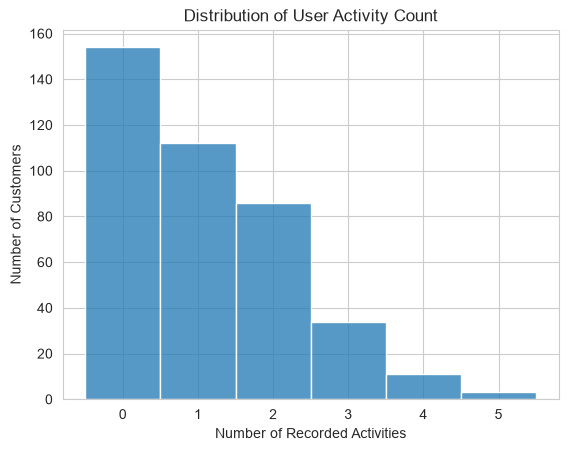

In [142]:
ax = sns.histplot(
    data=customer_analysis,
    x="activity_count",
    discrete=True
)

plt.title("Distribution of User Activity Count")
plt.xlabel("Number of Recorded Activities")
plt.ylabel("Number of Customers")

plt.show()

Liczba zarejestrowanych aktywności przypadających na klienta wynosi od 0 do 5.

Średnia wynosi około 1,11 zdarzenia.

    -> Znaczenie dla dalszej analizy: Należy zbadać, czy liczba zarejestrowanych aktywności jest związana z churn.

***6. Pytanie analityczne:*** Jakie rodzaje aktywności są najczęściej rejestrowane w aplikacji Fit.ly?

In [143]:
activity_full["event_type"].value_counts()

event_type
read_article     125
watch_video      120
track_workout    108
share_workout     92
Name: count, dtype: int64

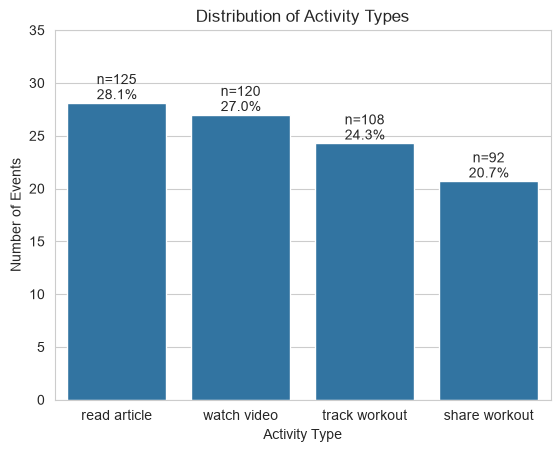

In [144]:
order = ['read_article', 'watch_video', 'track_workout', 'share_workout']

ax = sns.countplot(
    data=activity_full,
    x='event_type',
    stat='percent',
    order=order
)

ax.set_xticks(['read_article', 'watch_video', 'track_workout', 'share_workout'], labels=['read article', 'watch video', 'track workout', 'share workout'])

counts = activity_full["event_type"].value_counts().reindex(order, fill_value=0)

for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f'n={n}\n{p:.1f}%' for n, p in zip(counts, container.datavalues)]
    )

ax.set_ylim(0, 35)

plt.title("Distribution of Activity Types")
plt.xlabel("Activity Type")
plt.ylabel("Number of Events")
plt.show()

Najwięcej zarejestrowanych zdarzeń dotyczy czytania artykułów i oglądania filmów. Nieco mniej występuje zdarzeń związanych z rejestrowaniem i udostępnianiem treningów. Rozkład jest stosunkowo równomierny, choć read_article występuje częściej niż pozostałe rodzaje aktywności.

    -> Znaczenie dla dalszej analizy: Możemy zbadać, czy rodzaj zarejestrowanej aktywności jest związany z churn.
    Przykładowo warto sprawdzić, czy użytkownicy rejestrujący treningi mają inny udział rezygnacji niż użytkownicy, dla których nie odnotowano takiego zdarzenia.

***7. Pytanie analityczne:*** Jak rozkłada się liczba zgłoszeń do obsługi klienta wśród użytkowników Fit.ly?

In [145]:
customer_analysis["ticket_count"].describe()

count    400.00000
mean       2.29500
std        1.42761
min        0.00000
25%        1.00000
50%        2.00000
75%        3.00000
max        8.00000
Name: ticket_count, dtype: float64

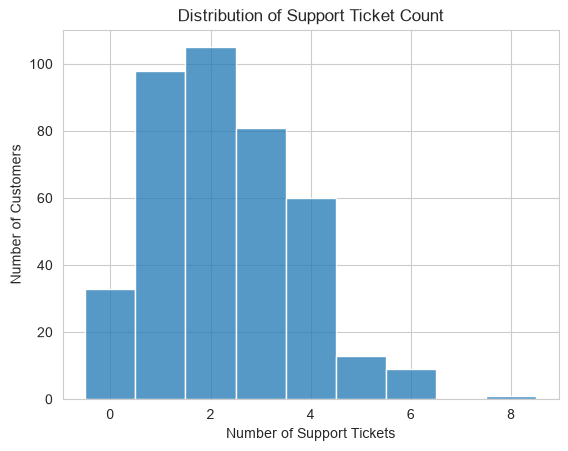

In [146]:
ax = sns.histplot(
    data=customer_analysis,
    x="ticket_count",
    discrete=True
)

plt.title("Distribution of Support Ticket Count")
plt.xlabel("Number of Support Tickets")
plt.ylabel("Number of Customers")

plt.show()

Liczba zgłoszeń przypadających na klienta wynosi od 0 do 8. Średnia wynosi około 2,30 zgłoszenia.

Najliczniejszą grupę stanowią klienci mający dwa zgłoszenia — 105 osób.

    -> Znaczenie dla dalszej analizy: Warto zbadać, czy liczba zgłoszeń jest związana z churn.

***8. Pytanie analityczne:*** Jakich problemów najczęściej dotyczą zgłoszenia klientów Fit.ly?

In [147]:
support_full["topic"].value_counts()

topic
billing      239
other        228
technical    226
account      225
Name: count, dtype: int64

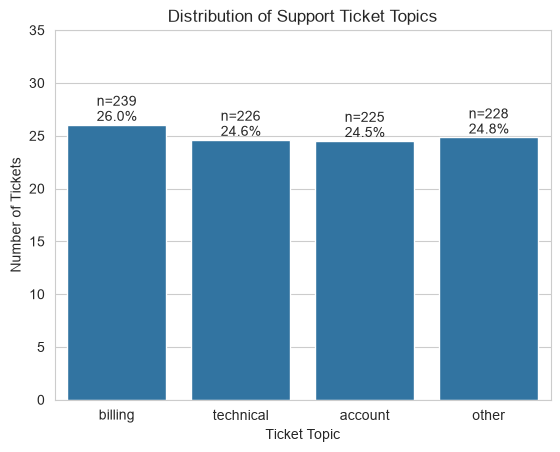

In [148]:
order = ['billing', 'technical', 'account', 'other']

ax = sns.countplot(
    data=support_full,
    x='topic',
    stat='percent',
    order=order
)

counts = support_full["topic"].value_counts().reindex(order, fill_value=0)

for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f'n={n}\n{p:.1f}%' for n, p in zip(counts, container.datavalues)]
    )

ax.set_ylim(0, 35)

plt.title("Distribution of Support Ticket Topics")
plt.xlabel("Ticket Topic")
plt.ylabel("Number of Tickets")
plt.show()

Najczęściej występującym tematem są rozliczenia — 239 zgłoszeń. Pozostałe kategorie mają bardzo podobne liczebności. Żaden temat zdecydowanie nie dominuje w strukturze zgłoszeń.

    -> Znaczenie dla dalszej analizy: Warto sprawdzić, czy klienci zgłaszający określone problemy częściej mają status churn.

***9. Pytanie analityczne:*** Jakimi kanałami klienci Fit.ly najczęściej kontaktują się z obsługą klienta?

In [149]:
support_full["channel"].value_counts()

channel
email      298
chat       294
phone      287
Unknown     39
Name: count, dtype: int64

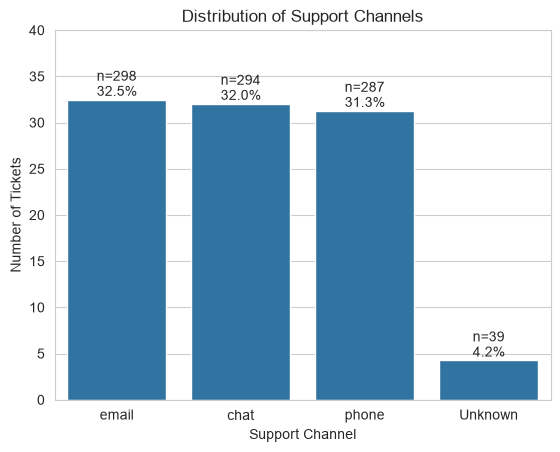

In [150]:
order = ['email', 'chat', 'phone', 'Unknown']

ax = sns.countplot(
    data=support_full,
    x="channel",
    stat='percent',
    order=order
)

counts = support_full["channel"].value_counts().reindex(order, fill_value=0)

for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f'n={n}\n{p:.1f}%' for n, p in zip(counts, container.datavalues)]
    )

ax.set_ylim(0, 40)

plt.title("Distribution of Support Channels")
plt.xlabel("Support Channel")
plt.ylabel("Number of Tickets")
plt.show()

Trzy znane kanały kontaktu mają bardzo zbliżoną liczbę zgłoszeń.

    -> Znaczenie dla dalszej analizy: Warto zbadać, czy czas rozwiązania problemu różni się między kanałami oraz czy sposób kontaktu jest związany z churn.

***Najważniejsze obserwacje z jednowymiarowej EDA***

Na podstawie wykonanej analizy możemy już stwierdzić, że:
- Baza klientów jest stosunkowo równomiernie podzielona między cztery plany.
- Udział klientów oznaczonych jako churned wynosi 28,5%, przy przyjętej interpretacji brakujących statusów.
- Dla 38,5% klientów nie mamy zarejestrowanej aktywności.
- Najwięcej zdarzeń dotyczy czytania artykułów i oglądania filmów.
- Średnia liczba zgłoszeń przypadająca na klienta wynosi około 2,30.
- Tematy zgłoszeń i znane kanały kontaktu mają stosunkowo równomierne rozkłady.
- Średni czas rozwiązania zgłoszenia wynosi 10,39 godziny.

### multivariate EDA ###

plan:
- Heatmapa przedstawiająca wyłącznie korelacje z churn.
- Szczegółowe wykresy najważniejszych zaobserwowanych zależności.
- Analiza łączna uwzględniająca plan, aktywność i zgłoszenia.

***1. Pytanie analityczne:*** Które cechy subskrypcji, zarejestrowanej aktywności i historii kontaktów z obsługą są związane ze statusem churn?

In [151]:
customer_analysis.columns.tolist()

['customer_id',
 'email',
 'state',
 'plan',
 'plan_list_price',
 'churn_status',
 'ticket_count',
 'topic_account',
 'topic_billing',
 'topic_other',
 'topic_technical',
 'channel_Unknown',
 'channel_chat',
 'channel_email',
 'channel_phone',
 'avg_resolution_hours',
 'max_resolution_hours',
 'activity_count',
 'event_read_article',
 'event_share_workout',
 'event_track_workout',
 'event_watch_video']

In [153]:
correlation_data = customer_analysis[
    [
        "churn_status",
        "plan",
        "plan_list_price",
        "activity_count",
        "event_read_article",
        "event_watch_video",
        "event_track_workout",
        "event_share_workout",
        "ticket_count",
        "topic_billing",
        "topic_technical",
        "topic_account",
        "topic_other",
        "channel_email",
        "channel_chat",
        "channel_phone",
        "channel_Unknown",
        "avg_resolution_hours",
        "max_resolution_hours"
    ]
].copy()

# Pomijamy identyfikatory, ponieważ ich wartości liczbowe nie mają znaczenia biznesowego.
# Nie wykorzystujemy również ticket_state_code, ponieważ dokumentacja nie wyjaśnia, co oznaczają wartości tego pola.

In [156]:
# zamiana churn_status na wartości liczbowe
correlation_data["churn"] = correlation_data["churn_status"].map({"N": 0, "Y": 1})
# i usuwamy kolumne tekstową:
correlation_data = correlation_data.drop(columns="churn_status")

In [157]:
# zamiana kolumy z planem na cztery osobne kolumny, gdzie 1 oznacza ten plan, a 0 brak tego planu
correlation_data = pd.get_dummies(correlation_data, columns=["plan"], dtype=int)

In [158]:
correlation_data.head()

,plan_list_price,activity_count,event_read_article,event_watch_video,event_track_workout,event_share_workout,ticket_count,topic_billing,topic_technical,topic_account,...,channel_chat,channel_phone,channel_Unknown,avg_resolution_hours,max_resolution_hours,churn,plan_Basic,plan_Enterprise,plan_Free,plan_Pro
0,105,3,2,1,0,0,3,1,0,1,...,1,0,0,21.446667,23.77,1,0,1,0,0
1,22,1,1,0,0,0,4,2,1,0,...,0,3,0,17.542500,26.44,1,1,0,0,0
2,24,1,1,0,0,0,3,0,1,0,...,2,0,0,6.433333,10.32,0,1,0,0,0
3,0,1,0,0,1,0,1,0,0,0,...,0,0,1,2.190000,2.19,0,0,0,1,0
4,119,4,0,3,1,0,4,2,2,0,...,1,1,1,8.542500,10.45,0,0,1,0,0


In [159]:
# obliczanie korelacji:
correlation_matrix = correlation_data.corr()
correlation_matrix.round(3)

,plan_list_price,activity_count,event_read_article,event_watch_video,event_track_workout,event_share_workout,ticket_count,topic_billing,topic_technical,topic_account,...,channel_chat,channel_phone,channel_Unknown,avg_resolution_hours,max_resolution_hours,churn,plan_Basic,plan_Enterprise,plan_Free,plan_Pro
plan_list_price,1.000,0.077,0.030,0.052,0.016,0.072,-0.066,-0.067,-0.019,-0.078,...,-0.002,-0.031,-0.004,-0.069,-0.074,-0.074,-0.345,0.871,-0.580,0.112
activity_count,0.077,1.000,0.551,0.565,0.558,0.490,-0.002,-0.003,-0.053,0.021,...,0.052,-0.037,0.005,-0.317,-0.326,-0.418,0.061,0.071,-0.094,-0.041
event_read_article,0.030,0.551,1.000,0.070,0.063,-0.016,0.034,0.031,-0.056,0.066,...,0.101,0.012,-0.003,-0.137,-0.140,-0.182,0.069,0.013,-0.078,-0.006
event_watch_video,0.052,0.565,0.070,1.000,0.079,0.051,0.021,0.020,-0.005,-0.036,...,0.052,-0.039,0.020,-0.109,-0.116,-0.156,-0.045,0.026,-0.016,0.040
event_track_workout,0.016,0.558,0.063,0.079,1.000,0.103,0.011,0.010,-0.007,0.016,...,-0.030,-0.038,0.074,-0.242,-0.247,-0.325,0.045,0.014,-0.038,-0.024
event_share_workout,0.072,0.490,-0.016,0.051,0.103,1.000,-0.080,-0.075,-0.047,-0.005,...,-0.021,-0.018,-0.086,-0.227,-0.230,-0.253,0.066,0.108,-0.072,-0.107
ticket_count,-0.066,-0.002,0.034,0.021,0.011,-0.080,1.000,0.505,0.502,0.455,...,0.549,0.497,0.216,0.047,0.252,0.067,0.024,-0.059,0.020,0.013
topic_billing,-0.067,-0.003,0.031,0.020,0.010,-0.075,0.505,1.000,-0.022,0.044,...,0.256,0.226,0.119,0.110,0.198,0.138,-0.011,-0.063,0.040,0.034
topic_technical,-0.019,-0.053,-0.056,-0.005,-0.007,-0.047,0.502,-0.022,1.000,-0.056,...,0.242,0.292,0.100,0.005,0.095,-0.010,0.039,0.000,-0.017,-0.024
topic_account,-0.078,0.021,0.066,-0.036,0.016,-0.005,0.455,0.044,-0.056,1.000,...,0.313,0.223,0.131,-0.017,0.073,-0.001,0.113,-0.065,-0.008,-0.050


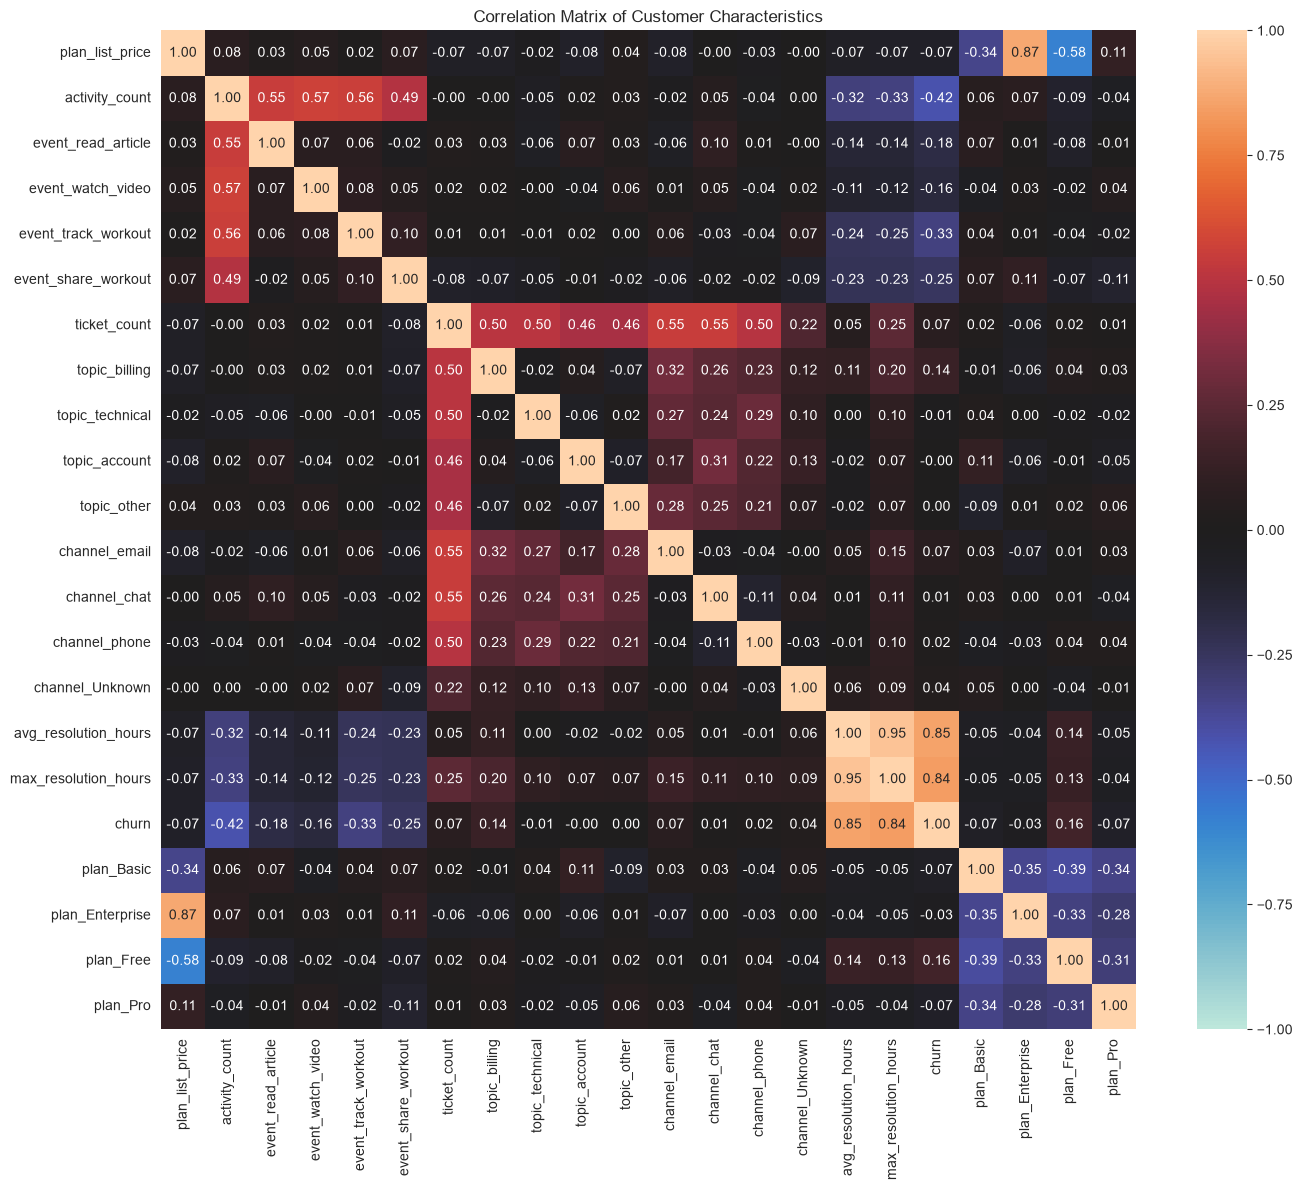

In [162]:
plt.figure(figsize=(14, 12))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    center=0,
    vmin=-1,
    vmax=1
)

plt.title("Correlation Matrix of Customer Characteristics")

plt.tight_layout()
plt.show()

In [ ]:
# korelacja tylko dla churn 

***Pytanie analityczne:*** Które badane zmienne wykazują najsilniejsze korelacje ze statusem churn?

In [163]:
churn_correlations = correlation_matrix[["churn"]]

In [164]:
# usuwamy korelacje z samym sobą
churn_correlations = churn_correlations.drop("churn")

In [166]:
# sortowanie
churn_correlations = churn_correlations.sort_values(by="churn")

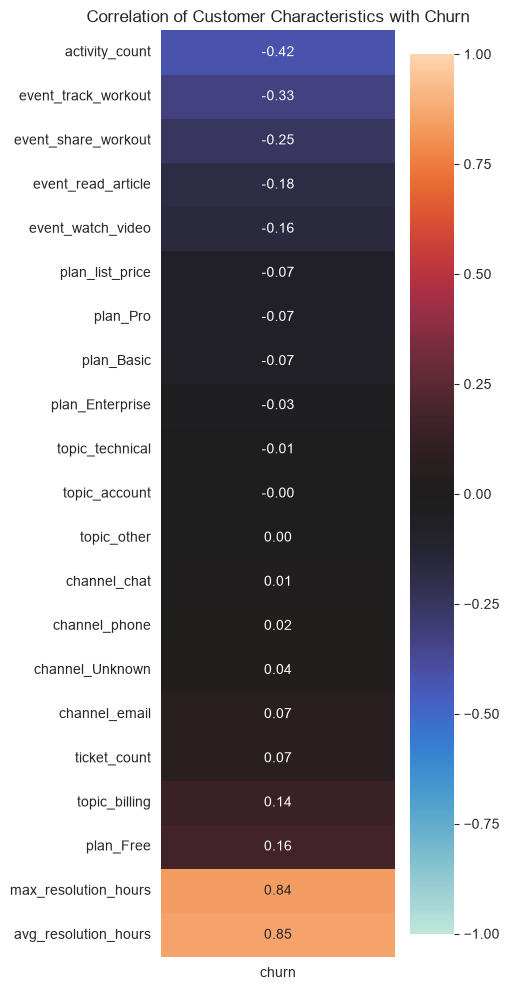

In [167]:
plt.figure(figsize=(5, 10))

sns.heatmap(
    churn_correlations,
    annot=True,
    fmt=".2f",
    center=0,
    vmin=-1,
    vmax=1
)

plt.title("Correlation of Customer Characteristics with Churn")

plt.tight_layout()
plt.show()

**Interpretacja**:

Największą dodatnią korelację ze statusem churn obserwujemy dla średniego czasu rozwiązania zgłoszenia (0,85) - klienci z dłuższymi czasami rozwiązania zgłoszeń znacznie częściej mają status churn. Podobną zależność obserwujemy dla maksymalnego czasu rozwiązania.

Liczba zarejestrowanych aktywności jest ujemnie skorelowana z churn (-0,42) - większa liczba zarejestrowanych zdarzeń współwystępuje z mniejszym udziałem klientów oznaczonych jako churned.

Plan Free wykazuje dodatnią korelację z churn (0,17) - przynależność do planu Free jest związana z większym udziałem rezygnacji w analizowanej próbie, ale zalkeżność ta jest znacznie słabsza

Liczba zgłoszeń billingowych wykazuje dodatnią korelację z churn (0,14) - za słaba zeby coś stwierdzić

Korelacja między całkowitą liczbą zgłoszeń a churn wynosi około 0,07  - za słaba zeby coś stwierdzić

**Wniosek z heatmapy:** średni czas rozwiązania zgłoszeń i liczba zarejestrowanych aktywności wykazują wyraźne związki ze statusem churn. Warto zbadać je dokładniej

***1. Pytanie analityczne:*** Czy klienci, którzy anulowali subskrypcję, mają dłuższe czasy rozwiązania zgłoszeń?

In [174]:
customer_analysis.groupby("churn_status")["avg_resolution_hours"].agg(["mean", "std", "min", "max", "median"])

,mean,std,min,max,median
churn_status,,,,,
N,6.659817,2.690913,0.990,14.256667,6.610417
Y,18.687580,4.609017,6.745,32.460000,18.630000


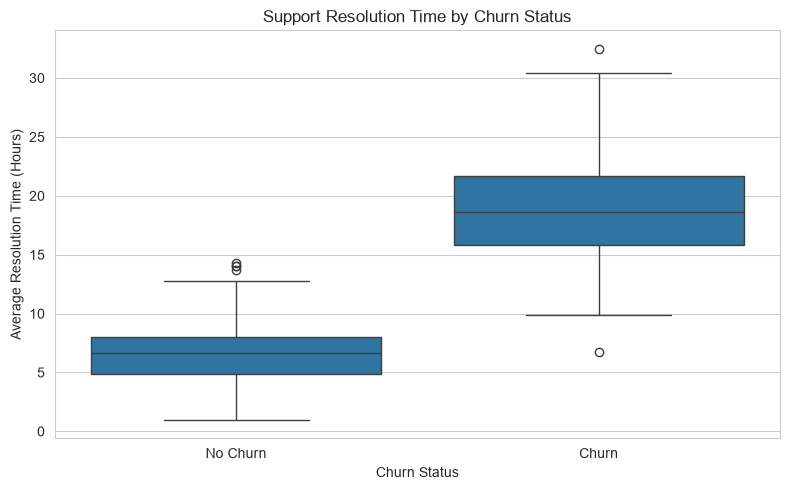

In [169]:
plt.figure(figsize=(8, 5))

ax = sns.boxplot(
    data=customer_analysis,
    x="churn_status",
    y="avg_resolution_hours",
    order=["N", "Y"]
)

ax.set_xticks(['N', 'Y'], labels=['No Churn', 'Churn'])

plt.title("Support Resolution Time by Churn Status")
plt.xlabel("Churn Status")
plt.ylabel("Average Resolution Time (Hours)")

plt.tight_layout()
plt.show()

Test t Welcha

- H₀: średni czas rozwiązania jest taki sam w obu grupach.
- H₁: średni czas rozwiązania różni się między grupami.


In [175]:
# przygotowanie grup - usuwamy klientów bez czasów rozwiązania

churn_yes = customer_analysis.loc[customer_analysis["churn_status"] == "Y","avg_resolution_hours"].dropna()
churn_no = customer_analysis.loc[customer_analysis["churn_status"] == "N", "avg_resolution_hours"].dropna()

In [176]:
print("Y — liczba klientów:", len(churn_yes))
print("Y — średni czas:", churn_yes.mean())

print("N — liczba klientów:", len(churn_no))
print("N — średni czas:", churn_no.mean())

Y — liczba klientów: 109
Y — średni czas: 18.68757951070336
N — liczba klientów: 258
N — średni czas: 6.659817183462532


In [177]:
from scipy import stats

In [178]:
result = stats.ttest_ind(churn_yes, churn_no, equal_var=False)

In [179]:
print(result)

TtestResult(statistic=np.float64(25.472705602600687), pvalue=np.float64(1.9241023692640498e-54), df=np.float64(140.12450320368464))


In [180]:
print("Statystyka testowa:", result.statistic)
print("p-value:", result.pvalue)
print("95% confidence interval:", result.confidence_interval())

Statystyka testowa: 25.472705602600687
p-value: 1.9241023692640498e-54
95% confidence interval: ConfidenceInterval(low=np.float64(11.094239660842629), high=np.float64(12.96128499363903))


Among customers with support tickets, those marked as churned had a significantly longer average ticket resolution time than non-churned customers (18.69 vs. 6.66 hours). A Welch’s t-test confirmed a statistically significant difference (p < 0.001), with a mean difference of 12.03 hours (95% CI: 11.09–12.96). This finding indicates a strong association between support resolution time and churn status, but does not establish causality.

***2. Pytanie analityczne:*** Jak zmienia się udział klientów oznaczonych jako churned w zależności od liczby zarejestrowanych aktywności?

In [184]:
#udział churn dla każdej liczby aktywności.
activity_churn = pd.crosstab(customer_analysis["activity_count"], customer_analysis["churn_status"], normalize="index")["Y"] * 100

In [188]:
activity_churn = activity_churn.reset_index(name="churn_pct")

In [189]:
activity_churn

,activity_count,churn_pct
0,0,53.896104
1,1,21.428571
2,2,5.813953
3,3,2.941176
4,4,9.090909
5,5,0.000000


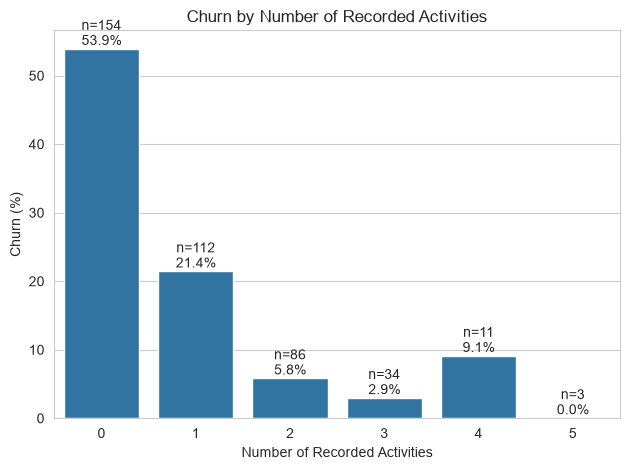

In [198]:
order = sorted(activity_churn["activity_count"].unique())

counts = customer_analysis["activity_count"].value_counts().reindex(order)

ax = sns.barplot(
    data=activity_churn,
    x="activity_count",
    y="churn_pct",
    order=order
)

for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f'n={n}\n{p:.1f}%'for n, p in zip(counts, container.datavalues)])

plt.title("Churn by Number of Recorded Activities")
plt.xlabel("Number of Recorded Activities")
plt.ylabel("Churn (%)")

plt.tight_layout()
plt.show()

Wyrażna zależność między liczbą zarejestrowanych aktywności a churn. Wśród klientów bez zarejestrowanej aktywności udział oznaczeń churn wynosi 53,9%.
Wśród klientów z dwiema aktywnościami jest to 5,8%.

Test Chi-kwadrat

- H₀: Liczba zarejestrowanych aktywności i status churn są niezależne.
- H₁: Istnieje zależność między liczbą zarejestrowanych aktywności a statusem churn.

In [199]:
# Grupy z 4 i 5 aktywnościami są bardzo małe. 
# W pełnej tabeli niektóre oczekiwane liczebności wynoszą mniej niż 5, co utrudnia stosowanie klasycznego testu chi-kwadrat.
# łączymy grupy 3, 4 i 5 w grupę (3 lub więcej)

In [200]:
customer_analysis["activity_group"] = pd.cut(customer_analysis["activity_count"], bins=[-1, 0, 1, 2, float("inf")], labels=["0", "1", "2", "3+"])

In [211]:
activity_table = pd.crosstab(customer_analysis["activity_group"],customer_analysis["churn_status"])
activity_table

churn_status,N,Y
activity_group,,
0,71,83
1,88,24
2,81,5
3+,46,2


In [203]:
from scipy.stats import chi2_contingency

In [230]:
chi2, p_value, dof, expected = chi2_contingency(activity_table)

print("Chi-square:", chi2)
print("p-value:", p_value)
print("Degrees of freedom:", dof)
print("Minimum expected count:", expected.min())

Chi-square: 87.158161621275
p-value: 8.929755143774334e-19
Degrees of freedom: 3
Minimum expected count: 13.68


In [207]:
# Najmniejsza oczekiwana liczebność wynosi 13,68, więc po połączeniu małych grup nie mamy problemu z oczekiwanymi liczebnościami poniżej 5.

In [212]:
activity_churn = pd.crosstab(customer_analysis["activity_group"],customer_analysis["churn_status"],normalize="index")["Y"] * 100
activity_churn = activity_churn.reset_index(name="churn_pct")

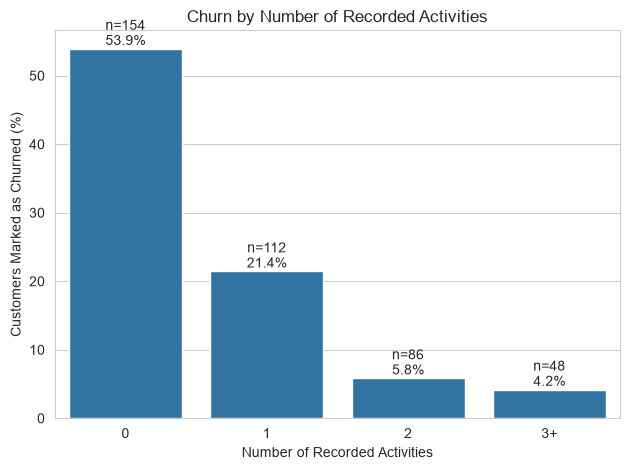

In [217]:
order = sorted(activity_churn["activity_group"].unique())

counts = customer_analysis["activity_group"].value_counts().reindex(order)

ax = sns.barplot(
    data=activity_churn,
    x="activity_group",
    y="churn_pct"
)

for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f'n={n}\n{p:.1f}%'for n, p in zip(counts, container.datavalues)])

plt.title("Churn by Number of Recorded Activities")
plt.xlabel("Number of Recorded Activities")
plt.ylabel("Customers Marked as Churned (%)")

plt.tight_layout()
plt.show()

W grupie bez zarejestrowanej aktywności udział churn wynosi 53,9%, podczas gdy w grupie z co najmniej trzema aktywnościami wynosi 4,2%.

Test chi-kwadrat wskazuje, że zależność między grupą aktywności a statusem churn jest statystycznie istotna: χ²(3) = 87,16; p < 0,001. Odrzucamy zatem hipotezę zerową o niezależności zmiennych.

Udział churn różni się między grupami aktywności. Sam test chi-kwadrat nie dowodzi jednak, że każdy kolejny poziom aktywności obniża churn, ani że aktywność powoduje mniejszą liczbę rezygnacji.

**User Activity and Churn**

The proportion of customers marked as churned differed across recorded activity groups. It was 53.9% among customers with no recorded activity, compared with 4.2% among customers with three or more recorded activities.

A chi-square test of independence confirmed a statistically significant association between activity group and churn status (χ²(3) = 87.16, p < 0.001).

The results indicate that recorded engagement is associated with churn status. However, they do not establish causality. Missing activity logs and the absence of cancellation dates limit the interpretation of this relationship.


***Pytanie analityczne:*** Jak udział churn różni się między klientami o różnym poziomie zarejestrowanej aktywności i różnej historii zgłoszeń dotyczących rozliczeń?

In [218]:
combined_analysis = customer_analysis.copy()

In [221]:
# zmienna pomocnicza czy jest churn
combined_analysis["churn_binary"] = (combined_analysis["churn_status"] == "Y").astype(int)

In [222]:
# zmienna pomocnicza czy klient miał przynajmniej jedno zgłoszenie
combined_analysis["has_billing"] = (combined_analysis["topic_billing"] > 0)

In [223]:
# zmienna pomocnicza czy zy klient ma zarejestrowaną aktywność
combined_analysis["has_activity"] = (combined_analysis["activity_count"] > 0)

In [224]:
# obliczanie udziału churn

combined_churn = combined_analysis.pivot_table(
    index="has_activity",
    columns="has_billing",
    values="churn_binary",
    aggfunc="mean"
) * 100

In [225]:
combined_churn.round(1)

has_billing,False,True
has_activity,,
False,47.6,61.4
True,8.3,17.7


Największy udział churn obserwujemy wśród klientów bez zarejestrowanej aktywności, którzy mieli przynajmniej jedno zgłoszenie dotyczące rozliczeń.
W tej grupie wynosi on 61,4%.

Najmniejszy udział występuje wśród klientów z zarejestrowaną aktywnością, którzy nie mieli zgłoszeń billingowych — 8,3%.

**Test Chi-kwadrat**

- H₀: Status churn jest niezależny od przynależności do jednej z czterech grup.
- H₁: Status churn jest związany z przynależnością do grupy — udział churn nie jest taki sam we wszystkich czterech grupach.

In [227]:
combined_table = pd.crosstab([combined_analysis["has_activity"],combined_analysis["has_billing"]],combined_analysis["churn_status"])
combined_table

churn_status                N   Y
has_activity has_billing         
False        False         44  40
             True          27  43
True         False        122  11
             True          93  20

In [228]:
# „Brak zgłoszenia billingowego” oznacza, że nie znaleziono takiego zgłoszenia. Klient mógł mieć zgłoszenia dotyczące innych tematów.

In [229]:
chi2, p_value, dof, expected = chi2_contingency(combined_table)

print("Chi-square:", chi2)
print("p-value:", p_value)
print("Degrees of freedom:", dof)
print("Minimum expected count:", expected.min())

Chi-square: 85.49381527098292
p-value: 2.0330819146681242e-18
Degrees of freedom: 3
Minimum expected count: 19.95


Najmniejsza oczekiwana liczebność wynosi 19,95, więc nie mamy problemu z małymi oczekiwanymi liczebnościami. Nie musimy łączyć żadnych grup.

Największy udział churn występuje wśród klientów bez zarejestrowanej aktywności, którzy mieli zgłoszenie billingowe — 61,4%.

Najmniejszy udział występuje wśród klientów z zarejestrowaną aktywnością i bez zgłoszenia billingowego — 8,3%.

Test chi-kwadrat wykazał statystycznie istotny związek między przynależnością do jednej z czterech grup a statusem churn: χ²(3) = 85,49; p < 0,001. Odrzucamy hipotezę zerową o niezależności. Udział churn nie jest taki sam we wszystkich czterech grupach.

Test nie dowodzi, że zgłoszenia billingowe powodują churn ani że obie cechy oddziałują na siebie. Wynik może w dużej mierze odzwierciedlać wcześniej zaobserwowany związek między aktywnością a churn. 

Engagement, Billing Support and Churn

Churn-flagged shares differed across the four customer groups defined by recorded activity and billing support history. The highest share was observed among customers with no recorded activity and at least one billing-related ticket (61.4%). The lowest share was observed among customers with recorded activity and no billing-related tickets (8.3%).

A chi-square test of independence confirmed a statistically significant association between customer group and churn status (χ²(3) = 85.49, p < 0.001).
The test establishes an association between the combined group classification and churn status. It does not establish causality or demonstrate an interaction between activity and billing support history.


***Pytanie analityczne:*** Czy rodzaj zarejestrowanej aktywności jest związany ze statusem churn?

In [232]:
# nie wykonamy jednego testu chi-kwadrat, w którym cztery rodzaje aktywności będą rozłącznymi grupami klientów. 
# Jeden klient mógł bowiem wykonać kilka rodzajów aktywności. 
#Zamiast tego dla każdego rodzaju sprawdzimy, czy klient wykonał go przynajmniej raz, i porównamy go z pozostałymi aktywnymi klientami.

In [233]:
active_customers = customer_analysis[customer_analysis["activity_count"] > 0].copy()
active_customers["churn_binary"] = (active_customers["churn_status"] == "Y").astype(int)

In [234]:
# dane do wykresu, udział churn wśród klientów, którzy wykonali dany rodzaj aktywności, oraz tych, którzy go nie wykonali.
activity_long = active_customers.melt(
    id_vars=["customer_id", "churn_binary"],
    value_vars=[
        "event_read_article",
        "event_watch_video",
        "event_track_workout",
        "event_share_workout"
    ],
    var_name="event_type",
    value_name="event_count"
)

In [235]:
# czy dany rodzaj aktywności został zarejestrowany?
activity_long["has_event"] = activity_long["event_count"] > 0

In [237]:
# udział churn
activity_rates = activity_long.groupby(["event_type", "has_event"])["churn_binary"].mean().reset_index(name="churn_pct")
activity_rates["churn_pct"] = activity_rates["churn_pct"] * 100

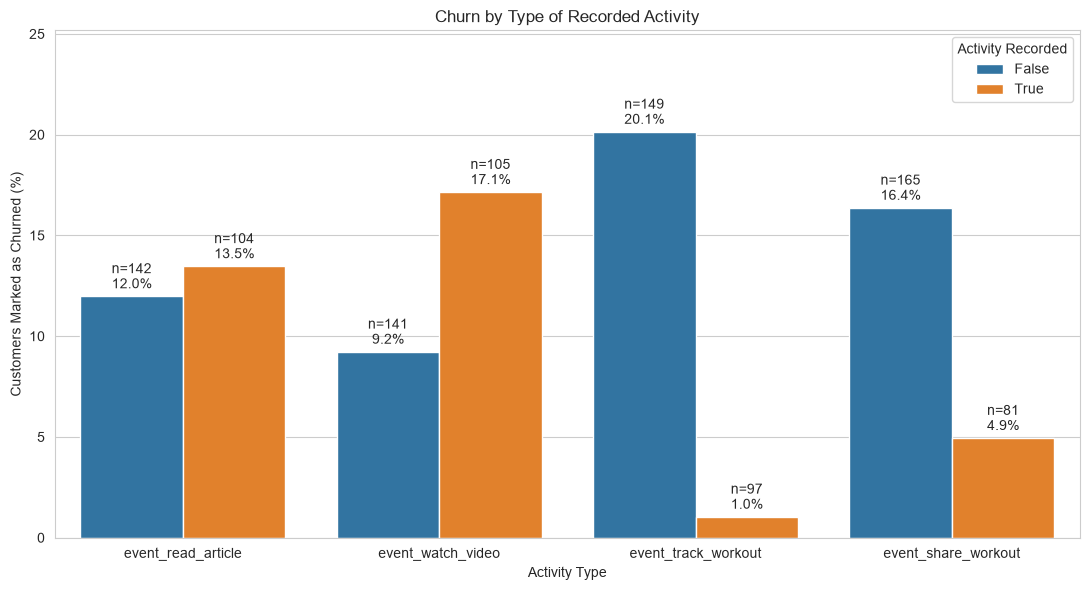

In [241]:
activity_rates = activity_long.groupby(["event_type", "has_event"]).agg(n=("customer_id", "nunique"),churn_pct=("churn_binary", "mean")).reset_index()

activity_rates["churn_pct"] = activity_rates["churn_pct"] * 100

order = ["event_read_article", "event_watch_video", "event_track_workout", "event_share_workout"]

plt.figure(figsize=(11, 6))

ax = sns.barplot(
    data=activity_rates,
    x="event_type",
    y="churn_pct",
    hue="has_event",
    order=order,
    hue_order=[False, True]
)

# Etykiety nad słupkami
for container, has_event in zip(ax.containers, [False, True]):

    labels_data = activity_rates[activity_rates["has_event"] == has_event].set_index("event_type").reindex(order)
    ax.bar_label(
        container,
        labels=[
            f"n={n}\n{p:.1f}%"
            for n, p in zip(
                labels_data["n"],
                labels_data["churn_pct"]
            )
        ],
        padding=3
    )

plt.title("Churn by Type of Recorded Activity")
plt.xlabel("Activity Type")
plt.ylabel("Customers Marked as Churned (%)")

plt.ylim(0, activity_rates["churn_pct"].max() * 1.25)
plt.legend(title="Activity Recorded")

plt.tight_layout()
plt.show()

Jak czytać etykiety? Na każdym słupku n oznacza liczbę klientów w danej grupie, a % — odsetek klientów ze statusem Y w tej grupie.

Przykładowo przy event_track_workout:

- True — klienci, którzy przynajmniej raz zarejestrowali trening;
- False — klienci, którzy mieli inne zarejestrowane aktywności, ale nie zarejestrowali treningu.
  
Ważne: na tym wykresie analizujemy tylko 246 klientów z co najmniej jedną zarejestrowaną aktywnością. Dlatego n dla pary słupków dotyczących każdego rodzaju aktywności sumuje się do 246.

Największe różnice obserwujemy dla rejestrowania i udostępniania treningów. Klienci, u których odnotowano te aktywności, mają niższy udział churn niż pozostali aktywni klienci.

**Test Fishera** bo małe liczebnośc

- H₀: Wykonanie danego rodzaju aktywności i status churn są niezależne.
- H₁: Wykonanie danego rodzaju aktywności jest związane ze statusem churn.

In [244]:
from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests

In [245]:
# tabele z danymi:

read_table = pd.crosstab(active_customers["event_read_article"] > 0, active_customers["churn_status"])
video_table = pd.crosstab(active_customers["event_watch_video"] > 0, active_customers["churn_status"])
track_table = pd.crosstab(active_customers["event_track_workout"] > 0, active_customers["churn_status"])
share_table = pd.crosstab(active_customers["event_share_workout"] > 0, active_customers["churn_status"])

In [246]:
# testy:
read_test = fisher_exact(read_table)
video_test = fisher_exact(video_table)
track_test = fisher_exact(track_table)
share_test = fisher_exact(share_table)

In [248]:
# cztery testy, więc korekta wielokrotnych porównań Holma:
p_adjusted = multipletests([read_test.pvalue, video_test.pvalue, track_test.pvalue, share_test.pvalue],method="holm")[1]

print("read_article:", p_adjusted[0])
print("watch_video:", p_adjusted[1])
print("track_workout:", p_adjusted[2])
print("share_workout:", p_adjusted[3])

read_article: 0.8461473513574298
watch_video: 0.16071234975119453
track_workout: 7.493307069741173e-06
share_workout: 0.0391783703729777


Wśród klientów z zarejestrowaną aktywnością rejestrowanie treningów (track_workout) oraz udostępnianie treningów (share_workout) są statystycznie istotnie związane ze statusem churn. 
W obu przypadkach udział churn jest niższy w grupie klientów, którzy wykonali daną aktywność.

Nie stwierdziliśmy natomiast statystycznie istotnej zależności dla czytania artykułów i oglądania filmów po uwzględnieniu korekty na cztery testy.

Nie oznacza to, że samo rejestrowanie lub udostępnianie treningów zapobiega rezygnacji. Osoby wykonujące te działania mogą po prostu korzystać z aplikacji intensywniej. Aby oddzielić rodzaj aktywności od jej łącznej liczby, potrzebna byłaby dodatkowa analiza uwzględniająca obie cechy jednocześnie.

Activity Type and Churn

Among the 246 customers with recorded activity, churn-flagged shares varied by activity type. Customers who recorded a workout had a churn-flagged share of 1.0%, compared with 20.1% among other active customers. For customers who shared a workout, the corresponding shares were 4.9% and 16.4%.

Fisher’s exact tests, with Holm correction for four comparisons, indicated statistically significant associations for workout tracking (adjusted p < 0.001) and workout sharing (adjusted p = 0.039). No statistically significant associations were found for article reading or video watching after correction.

These results suggest that workout-related activities warrant further investigation in relation to churn. However, the analysis does not establish causality or isolate activity type from overall engagement. The findings apply only to customers with at least one recorded activity.


Multivariate Analysis Conclusion

The multivariate analysis identified statistically significant associations between customer churn, recorded user activity, and customer support experiences. Customers with no recorded activity had a substantially higher churn-flagged share than customers with more recorded activities. Among customers who contacted support, those marked as churned had significantly longer average ticket resolution times (18.69 versus 6.66 hours; Welch’s t-test, p < 0.001).

Activity type was also associated with churn. Among the 246 customers with at least one recorded activity, those who tracked workouts had a lower churn-flagged share than other active customers (1.0% versus 20.1%). A similar pattern was observed for workout sharing (4.9% versus 16.4%). Both associations were statistically significant after correcting for multiple comparisons. No statistically significant associations were found for reading articles or watching videos.

The combined analysis showed that customers with no recorded activity and at least one billing-related ticket had the highest observed churn-flagged share (61.4%). Customers with recorded activity and no billing-related tickets had the lowest share (8.3%). A chi-square test confirmed a statistically significant association between these customer groups and churn status (χ²(3) = 85.49, p < 0.001).

Overall, the findings highlight recorded engagement—particularly workout-related activity—and support resolution time as relevant areas for further investigation. However, these observational results do not establish causality. The activity-type comparisons do not isolate activity type from overall engagement, and the combined chi-square test does not establish an interaction between activity and billing support history. Interpretation is further limited by potentially incomplete activity records, the absence of cancellation dates, and the assumption that missing churn statuses indicate non-churned customers.

**KOŃCOWE WNIOSKI**

The exploratory data analysis covered 400 Fit.ly customers across four subscription plans. Basic was the most common plan, while the Free plan had the highest observed churn-flagged share (41.0%). Overall, 114 customers (28.5%) were marked as churned, based on the assumption that missing churn statuses indicate non-churned customers. This figure represents the share of churn-flagged customers in the dataset, not a monthly churn rate.

The univariate analysis showed that 38.5% of customers had no recorded activity. Article reading and video watching were the most frequently recorded event types. Customer support tickets were distributed relatively evenly across topics and known communication channels, with an average resolution time of 10.39 hours.

The multivariate analysis revealed statistically significant associations between churn and several aspects of customer engagement and support. Customers with no recorded activity had a higher churn-flagged share than more active customers. Among customers with support tickets, those marked as churned had significantly longer average resolution times (18.69 versus 6.66 hours; p < 0.001).

The analysis of activity types provided further detail. Among customers with recorded activity, workout tracking and workout sharing were associated with lower churn-flagged shares. These associations remained statistically significant after correction for multiple comparisons. Reading articles and watching videos did not show statistically significant associations after correction.

The combined analysis found the highest churn-flagged share among customers with no recorded activity and at least one billing-related ticket (61.4%), compared with 8.3% among customers with recorded activity and no billing-related tickets. The difference across the four customer groups was statistically significant (χ²(3) = 85.49, p < 0.001).
Taken together, the results suggest that recorded engagement, workout-related activity, and support experiences are important areas for further investigation. They provide a basis for developing and testing potential retention initiatives, but do not demonstrate that changing these factors would reduce churn. The findings must be interpreted in light of potentially incomplete activity records, unavailable cancellation dates, and the assumption used to classify missing churn statuses.